In [1]:
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np

from mdx2.io import loadobj
from mdx2.report.visualization import calc_isoavg, extract_central_slice, unique_slices

# Visualization

Plot slices through the merged reciprocal space map

## Parameters

In [2]:
# These metadata fields are injected by mdx2.report, regardless of the template. Don't change this line.
_metadata: dict = {}

# Notebook parameters
#input_files: list[str] = None # list of input file paths: required
crystal_source: str = None  # (nexus_file_path:object name)
symmetry_source: str = None  # (nexus_file_path:object name)
hkl_table_source: str = None  # (nexus_file_path:object name)

cartesian_coordinates: bool = None # whether to use cartesian coordinates (sx, sy) or Miller indices (h, k, l).

In [3]:
# Parameters
crystal_source = "../geometry.nxs:crystal"
symmetry_source = "../geometry.nxs:symmetry"
hkl_table_source = "../merged.nxs:hkl_table"
cartesian_coordinates = True
_metadata = {"author": "Steve Meisburger", "date_created": "2026-04-17 13:31:44", "mdx2_version": "1.0.3", "environment": "cbsuando2.biohpc.cornell.edu", "working_directory": "/local/storage/steve/mdx2_dev/examples/insulin-tutorial/reports", "notebook_template": "visualization"}


In [4]:
# pretty-print the metadata and parameters
pprint({
    "metadata": _metadata,
    "parameters": {"crystal_source": crystal_source,
                   "symmetry_source": symmetry_source,
                   "hkl_table_source": hkl_table_source,
                   "cartesian_coordinates": cartesian_coordinates,
                   },
})

{'metadata': {'author': 'Steve Meisburger',
              'date_created': '2026-04-17 13:31:44',
              'environment': 'cbsuando2.biohpc.cornell.edu',
              'mdx2_version': '1.0.3',
              'notebook_template': 'visualization',
              'working_directory': '/local/storage/steve/mdx2_dev/examples/insulin-tutorial/reports'},
 'parameters': {'cartesian_coordinates': True,
                'crystal_source': '../geometry.nxs:crystal',
                'hkl_table_source': '../merged.nxs:hkl_table',
                'symmetry_source': '../geometry.nxs:symmetry'}}


## Results

In [5]:
crystal = loadobj(*crystal_source.split(":"))
symmetry = loadobj(*symmetry_source.split(":"))
hkl_table = loadobj(*hkl_table_source.split(":"))

### Isotropic average

Calculated for all voxels that are not centered on a Bragg peak, for visualization purposes only.

Text(0, 0.5, 'Isotropic average intensity')

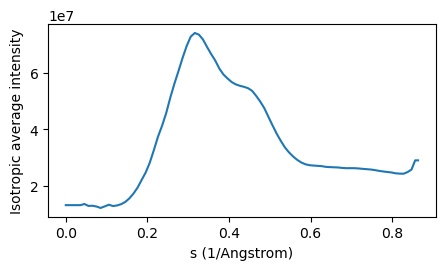

In [6]:
s_iso, intensity_iso = calc_isoavg(hkl_table, crystal) # bin_width=0.01, fraction=0.1 -- adjust if needed

plt.figure(figsize=(5,2.5))
plt.plot(s_iso, intensity_iso)
plt.xlabel("s (1/Angstrom)")
plt.ylabel("Isotropic average intensity")

### Reciprocal space slices

Plotting slice of constant l~0.0 in cartesian coordinates, with a* along sx and b* pointing upward.


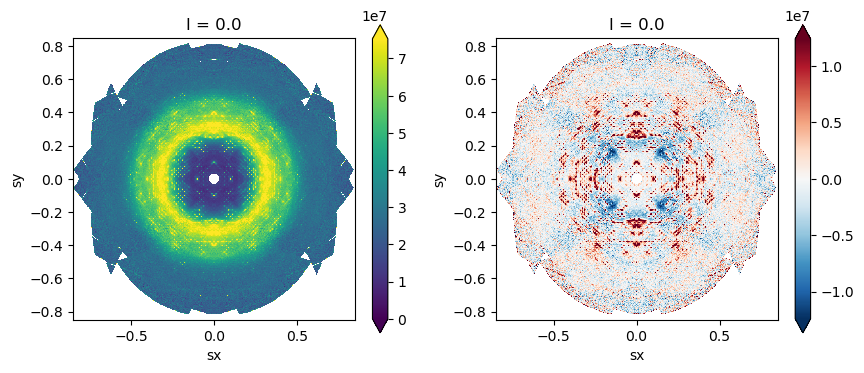

Plotting slice of constant l~0.5 in cartesian coordinates, with a* along sx and b* pointing upward.


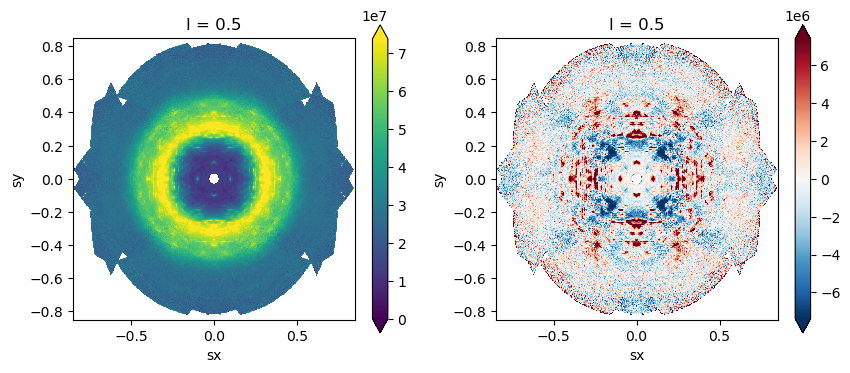

In [7]:
# a couple of helper functions for plotting
def _tighten_cartesian_axes(axes, da):
    """Set the x and y limits of the plot to be tight around the non-null values in cartesian space."""
    s = np.sqrt(da.sx**2 + da.sy**2)
    smax = s.where(da.notnull()).max().data
    for ax in axes:
        ax.set_xlim(-smax, smax)
        ax.set_ylim(-smax, smax)
        ax.set_aspect('equal', adjustable='box')

def _print_cartesian_slice_info(slice_index, coord):
    x_axis, y_axis, z_axis = np.roll(['a*', 'b*', 'c*'], 2 - slice_index)
    print(
        f"Plotting slice of constant {['h', 'k', 'l'][slice_index]}~{coord} in cartesian",
        f"coordinates, with {x_axis} along sx and {y_axis} pointing upward.",
    )

def subtract_isotropic_part(da, s_iso, intensity_iso):
    s = np.sqrt(da.sx**2 + da.sy**2 + da.sz**2)
    intensity_interp = np.interp(s, s_iso, intensity_iso)
    da_subtracted = da.copy()
    da_subtracted.data = da.data - intensity_interp
    return da_subtracted

for slice_index, coord in unique_slices(symmetry): # by default, non-central slices have coord set to offset=0.5
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    intensity = extract_central_slice(
        hkl_table,
        symmetry,
        crystal,
        slice_index=slice_index,
        slice_coordinate=coord, # for some grids, 0.5 may round to 1/3, etc.
        signal="intensity",
    )
    intensity_subtracted = subtract_isotropic_part(intensity, s_iso, intensity_iso)
    if cartesian_coordinates:
        _print_cartesian_slice_info(slice_index, coord)
        intensity.plot.pcolormesh("sx", "sy", vmin=0, robust=True, ax=ax[0])
        intensity_subtracted.plot.pcolormesh("sx", "sy", robust=True, cmap = 'RdBu_r', ax=ax[1])
        _tighten_cartesian_axes(ax, intensity)
    else: # the axes are Miller indices
        intensity.plot(robust=True, vmin=0, ax=ax[0])
        intensity_subtracted.plot(robust=True, cmap = 'RdBu_r', ax=ax[1])
        [a.set_box_aspect(1) for a in ax]
    plt.show()
